In [39]:
# load libraries 
library(dplyr)
library(Seurat)
library(HGNChelper)
library(openxlsx)
library(ggplot2)
library(tidyverse)
library(igraph)
library(data.tree)
library(ggraph)
library(stringr)
library(fedmatch)

# load functions
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/gene_sets_prepare.R")
source("https://raw.githubusercontent.com/IanevskiAleksandr/sc-type/master/R/sctype_score_.R")

# Set seed
set.seed(123456)

In [33]:
# load the data
dir1 = readline(prompt = "Please enter file directory to load LOG_NORM_NOVOALL_filt_integ_final.rds: ") # add .rds extension
LOG_NORM_NOVOALL_filt_integ_final = readRDS(dir1) 

# get cell-type-specific gene sets (from dataset of markers from research papers)
dir2 = readline(prompt = "Please enter file directory to gs_list: ")
gs_list = readRDS(dir2)

Please enter file directory to load LOG_NORM_NOVOALL_filt_integ_final.rds:  ../data_files2/LOG_NORM_NOVOALL_filt_integ_final.rds
Please enter file directory to gs_list:  ../raw_data/gs_list.rds


In [34]:
# general function to run PCA, find neighbours, cluster, sctype classification and umap
recluster_func = function (seurat_obj, dims = 1:30, resolution = 0.8, cluster_name = "recluster", umap_name = "umap_recluster"){

    # scale the data 
    seurat_obj = ScaleData(seurat_obj) 
    
    # PCA
    seurat_obj = RunPCA(seurat_obj)

    # Elbow plot
    ElbowPlot(seurat_obj)

    # Find Neighbours
    seurat_obj = FindNeighbors(seurat_obj, dims = dims, reduction = "pca")

    # Cluster
    seurat_obj = FindClusters(seurat_obj, resolution = resolution, cluster.name = cluster_name)

    # UMAP
    seurat_obj = RunUMAP(seurat_obj, dims = dims, reduction = "pca", reduction.name = umap_name)

    # SCType classification
    # check Seurat object version (scRNA-seq matrix extracted differently in Seurat v4/v5)
    seurat_package_v5 = isFALSE('counts' %in% names(attributes(seurat_obj[["RNA"]])));
    print(sprintf("Seurat object %s is used", ifelse(seurat_package_v5, "v5", "v4")))
    
    # extract scaled scRNA-seq matrix
    scRNAseqData_scaled <- if (seurat_package_v5) as.matrix(seurat_obj[["RNA"]]$scale.data) else as.matrix(seurat_obj[["RNA"]]@scale.data)
    
    # run ScType
    es.max <- sctype_score(scRNAseqData = scRNAseqData_scaled, scaled = TRUE, gs = gs_list$gs_positive, gs2 = gs_list$gs_negative)
    
    # NOTE: scRNAseqData parameter should correspond to your input scRNA-seq matrix. For raw (unscaled) count matrix set scaled = FALSE
    # When using Seurat, we use "RNA" slot with 'scale.data' by default. Please change "RNA" to "SCT" for sctransform-normalized data,
    # or to "integrated" for joint dataset analysis. To apply sctype with unscaled data, use e.g. pbmc[["RNA"]]$counts or pbmc[["RNA"]]@counts, with scaled set to FALSE.
    
    # merge by cluster (do.call combines the results for all clusters row by row using rbind into a single df) 
    cL_results = do.call("rbind", lapply(unique(seurat_obj@meta.data$seurat_clusters), function(cl){ # apply the function to every unique cluster id
        es.max.cl = sort(rowSums(es.max[ ,rownames(seurat_obj@meta.data[seurat_obj@meta.data$seurat_clusters==cl, ])]), # find the cells in cluster cl and compute row sums of es.max restricted to those cells
                         decreasing = !0) # sort in descending order (highest score first)
    
        # make dataframe of the top 10 features (classifications) for each cluster
        head(data.frame(cluster = cl, 
                        type = names(es.max.cl), 
                        scores = es.max.cl, # sum of scores for this cluster
                        ncells = sum(seurat_obj@meta.data$seurat_clusters==cl)), 10) # number of cells in the cluster, keep only top 10 
    }))
    
    sctype_scores = cL_results %>%
                    group_by(cluster) %>% 
                    top_n(n = 1, wt = scores) # wt is the variable used for ordering
    
    # set low-confident (low ScType score) clusters to "unknown"
    sctype_scores$type[as.numeric(as.character(sctype_scores$scores)) < sctype_scores$ncells/4] <- "Unknown"

    seurat_obj@meta.data$sctype_classification = "" # create new column
    for(j in unique(sctype_scores$cluster)){
      cl_type = sctype_scores[sctype_scores$cluster==j,]; # cell type annotation for cluster j 
      seurat_obj@meta.data$sctype_classification[seurat_obj@meta.data$seurat_clusters == j] = as.character(cl_type$type[1]) # for all cells whose cluster id = j, add the cell type classification
    }
    seurat_obj@meta.data$sctype_classification = clean_strings(seurat_obj@meta.data$sctype_classification)

    return(seurat_obj)
    
    }

### Note: the following filterations need not be done in order, depending on what you would like to filter, you may change the files!

## Filter data by sctype classification 

In [35]:
# The following is a list of all the unique sctype classifications available in this dataset
                                                # for the user to decide which ones to keep
LOG_NORM_NOVOALL_filt_integ_final@meta.data %>% select("sctype_classification") %>% distinct()

,sctype_classification
,<chr>
WT_S1_AGCTGAGTC_ACCAGGTCA_AACAAGTGG,rhom dims3ngranule cells a
WT_S1_CGCCAATGA_ATAGCGTGT_AACAAGTGG,dhabenula
WT_S1_GCTTGAGGT_ATGCCTAAG_AACAAGTGG,lymphocytes
WT_S1_CCTTGAATC_CAATGCAAC_AACAAGTGG,oligodendrocytes c
WT_S1_ACGAAGCTC_CTAACCAGA_AACAAGTGG,ventral forebrain dienc hyp poa gabaergic b
WT_S1_TGCGGTTCT_GAAGAAGCC_AACAAGTGG,tel dim s2nmidbrain thalamus
WT_S1_GCTTGAGGT_GTAATGGAC_AACAAGTGG,blood immune cell possibly b cells
WT_S1_CCTAGTCTT_TAGCGATGA_AACAAGTGG,hypothalamus a
WT_S1_CAGAGTACA_TCTTCTCAG_AACAAGTGG,torus long neurons


In [36]:
keep_clusters = readline(prompt = "Please indicate the clusters you would like to keep, separated only by a |: ")

# example entry: dhabenula|lymphocytes|nk like|radial glia|vhabenula|hypothalamus a|torus long neurons|rhom dims3ngranule cells a

keep_clusters = trimws(str_split_1(keep_clusters, "\\|"))

Please indicate the clusters you would like to keep, separated only by a |:  dhabenula|lymphocytes|nk like|radial glia|vhabenula|hypothalamus a|torus long neurons|rhom dims3ngranule cells a


In [37]:
sctype_filtered = subset(LOG_NORM_NOVOALL_filt_integ_final, subset = sctype_classification %in% keep_clusters)

In [41]:
LOG_NORM_NOVOALL_filt_integ_final_sc = recluster_func(sctype_filtered, 
                                             dims = 1:30, 
                                             resolution = 0.8, 
                                             cluster_name = "recluster", 
                                             umap_name = "umap_recluster")

Centering and scaling data matrix

Warning message:
“The following 5 features requested have zero variance; running reduction without them: ENSDARG00000077813, kifc1, ENSDARG00000097060, pbxip1b, ENSDARG00000100948”
PC_ 1 
Positive:  zgc:64051, ENSDARG00000105408, cd63, ENSDARG00000096655, cd74b, b2m, ENSDARG00000095562, mhc2daa, pfn1, srgn 
	   si:dkey-27i16.2, arpc1b, mhc1uba, itm2bb, cd74a, cxcr4b, ENSDARG00000101785, ENSDARG00000087645, zgc:162730, spi1b 
	   vsir, ENSDARG00000071437, lcp1, ENSDARG00000090396, txnipa, coro1a, ENSDARG00000055504, si:busm1-266f07.1, ucp2, ENSDARG00000114387 
Negative:  neurod1, nptx1l, egr4, nrn1a, scg2b, nrxn1a, ENSDARG00000105529, KDM6B, atp1b1b, ndrg3a 
	   etv1, dusp5, bdnf, hspa8b, etv5b, tcima, ENSDARG00000051970, scg3, vamp1a, cited4a 
	   NELL2, fosb, nppcl, islr2, mstnb, mag, chga, ENSDARG00000101606, ppp1r1c, dnajb4 
PC_ 2 
Positive:  gja13.2, cmklr1, plin3, spi1b, ncf2, slc22a21, havcr1, cebpa, ENSDARG00000076144, csf1ra 
	   slc3a2a, ENSD

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12502
Number of edges: 468337

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8489
Number of communities: 19
Elapsed time: 1 seconds


17:08:18 UMAP embedding parameters a = 0.9922 b = 1.112

17:08:18 Read 12502 rows and found 30 numeric columns

17:08:18 Using Annoy for neighbor search, n_neighbors = 30

17:08:18 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:08:19 Writing NN index file to temp file /var/folders/7b/snpms3c90nqg721sdk5lczdw0000gn/T//RtmpdV0v1z/file51347ef189d0

17:08:19 Searching Annoy index using 1 thread, search_k = 3000

17:08:21 Annoy recall = 100%

17:08:21 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:08:22 Found 2 connected components, 
falling back to 'spca' initialization with init_sdev = 1

17:08:22 Using 'irlba' for PCA

17:08:22 PCA: 2 components explained 41.36% variance

17:08:22 Scaling init to sdev = 1

17:08:22 Commenc

[1] "Seurat object v5 is used"


Enter the reduction name that was used earlier:  umap_recluster


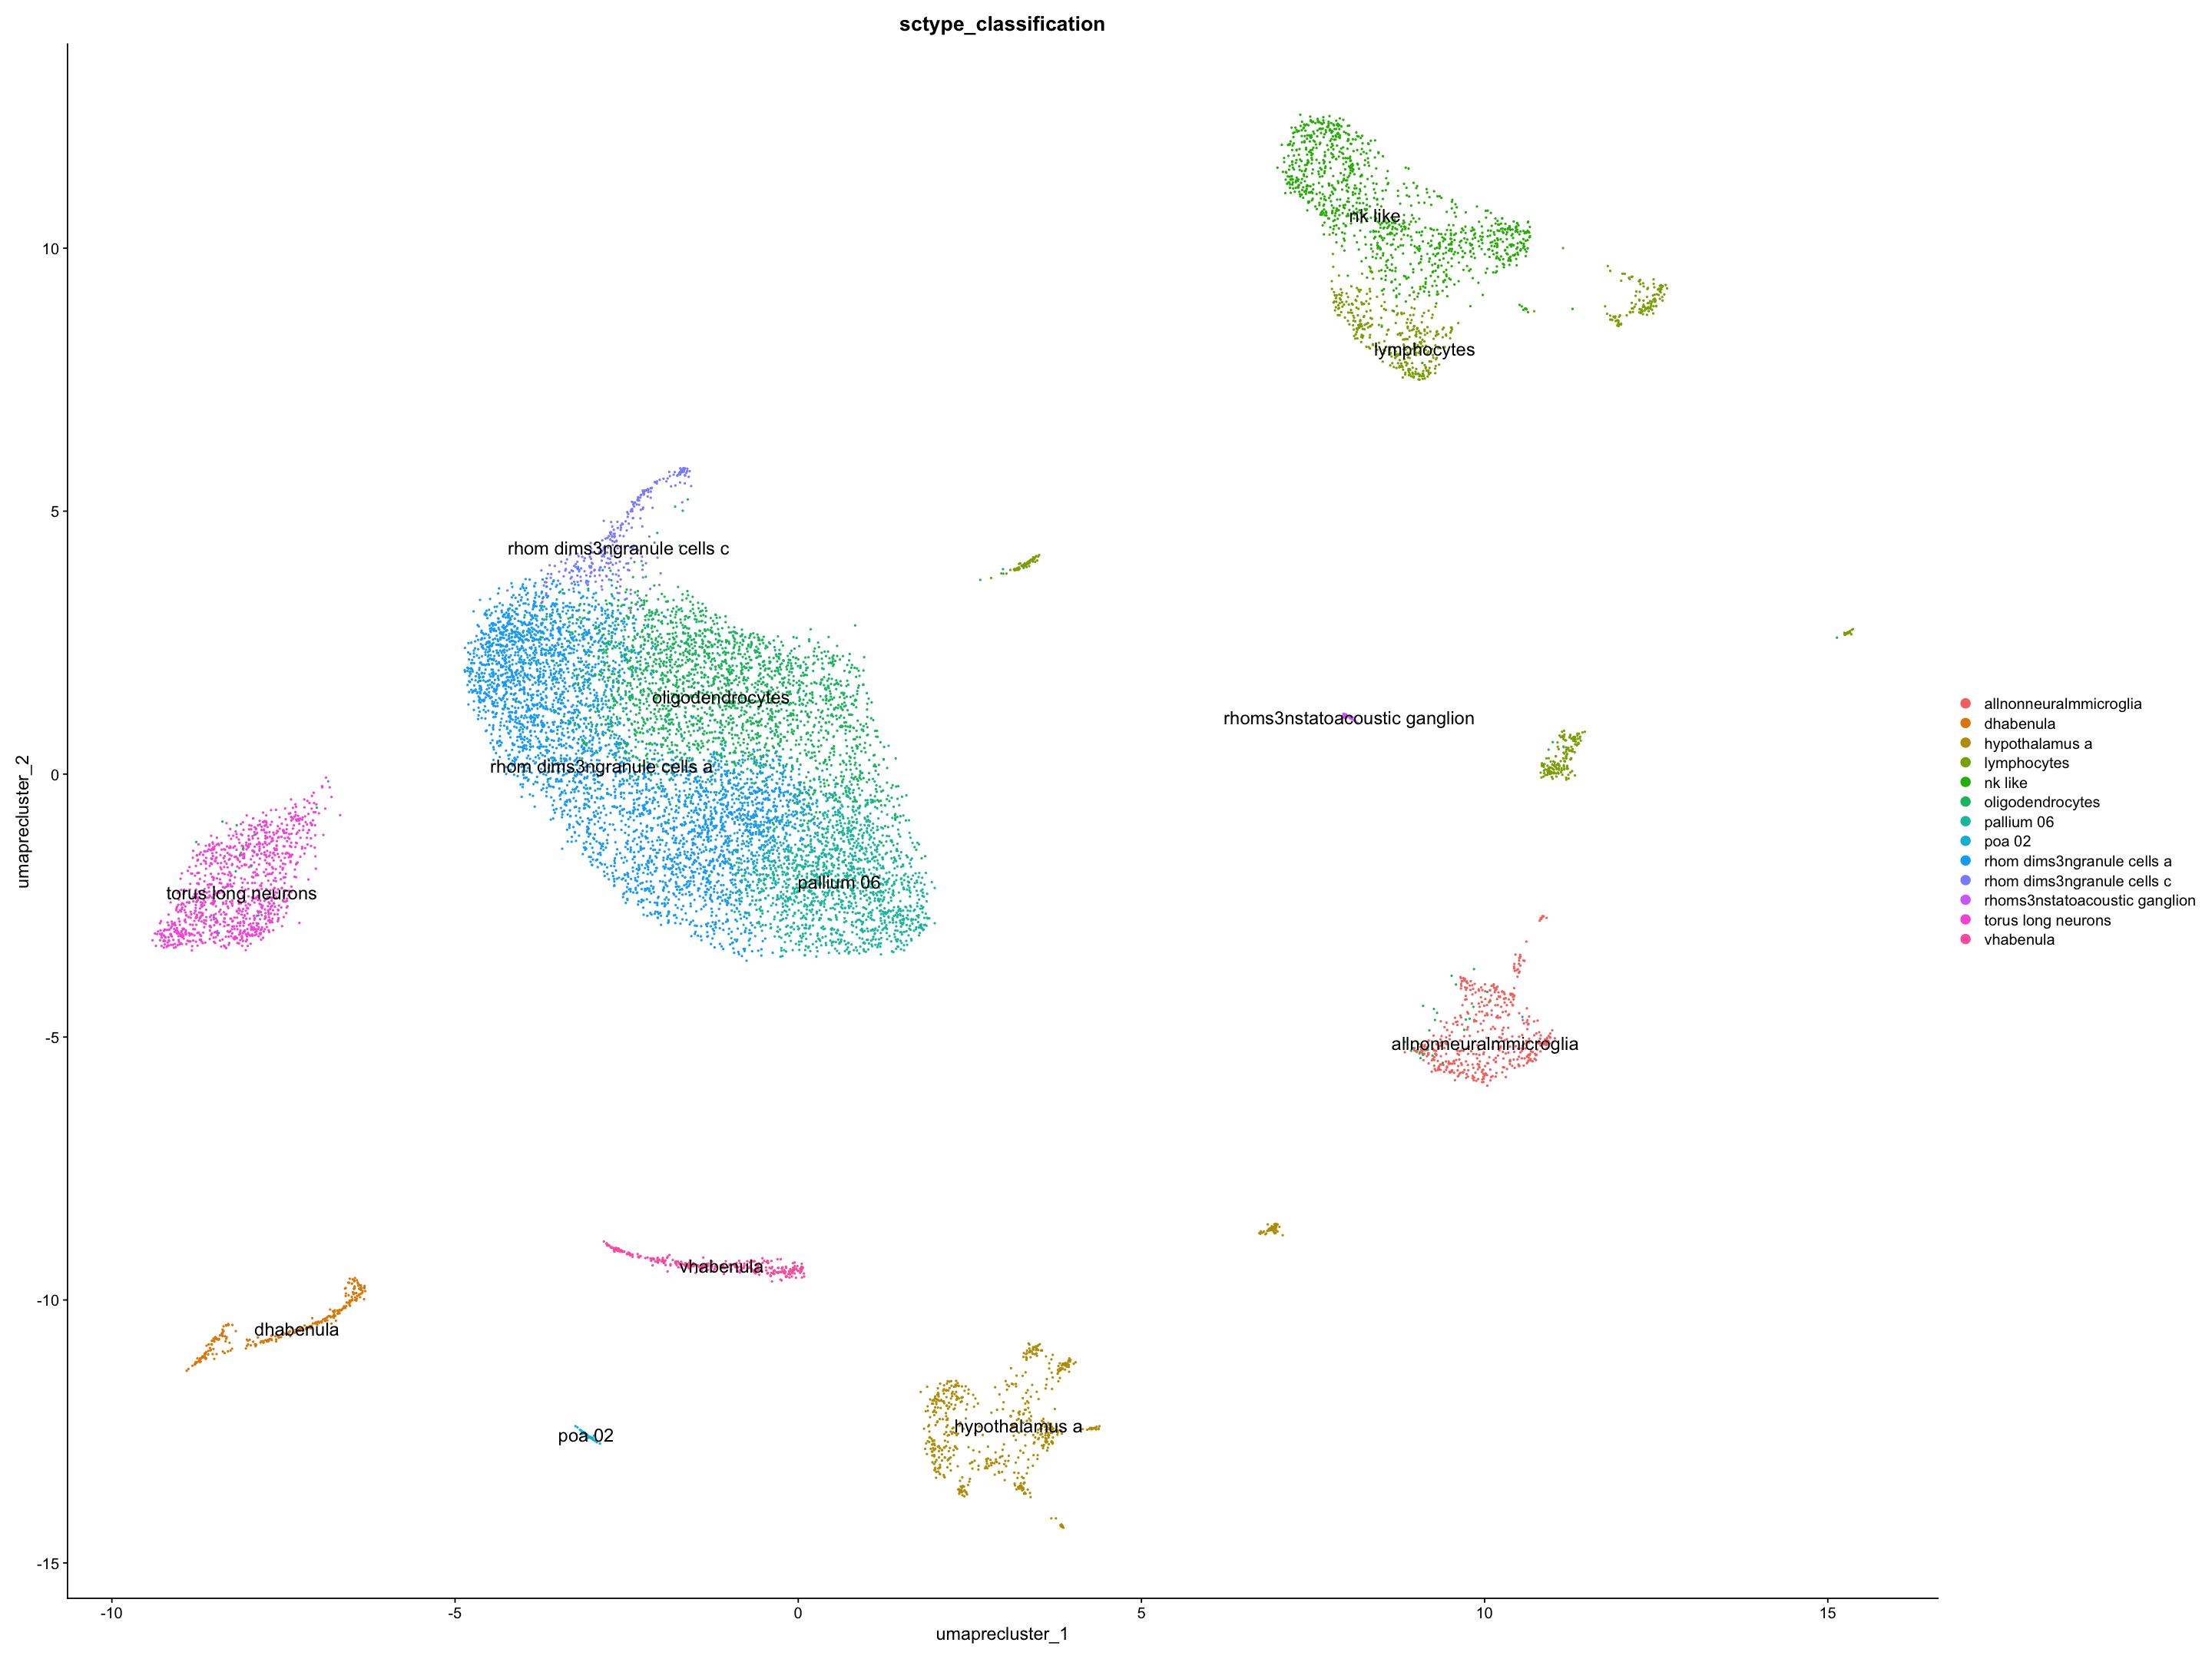

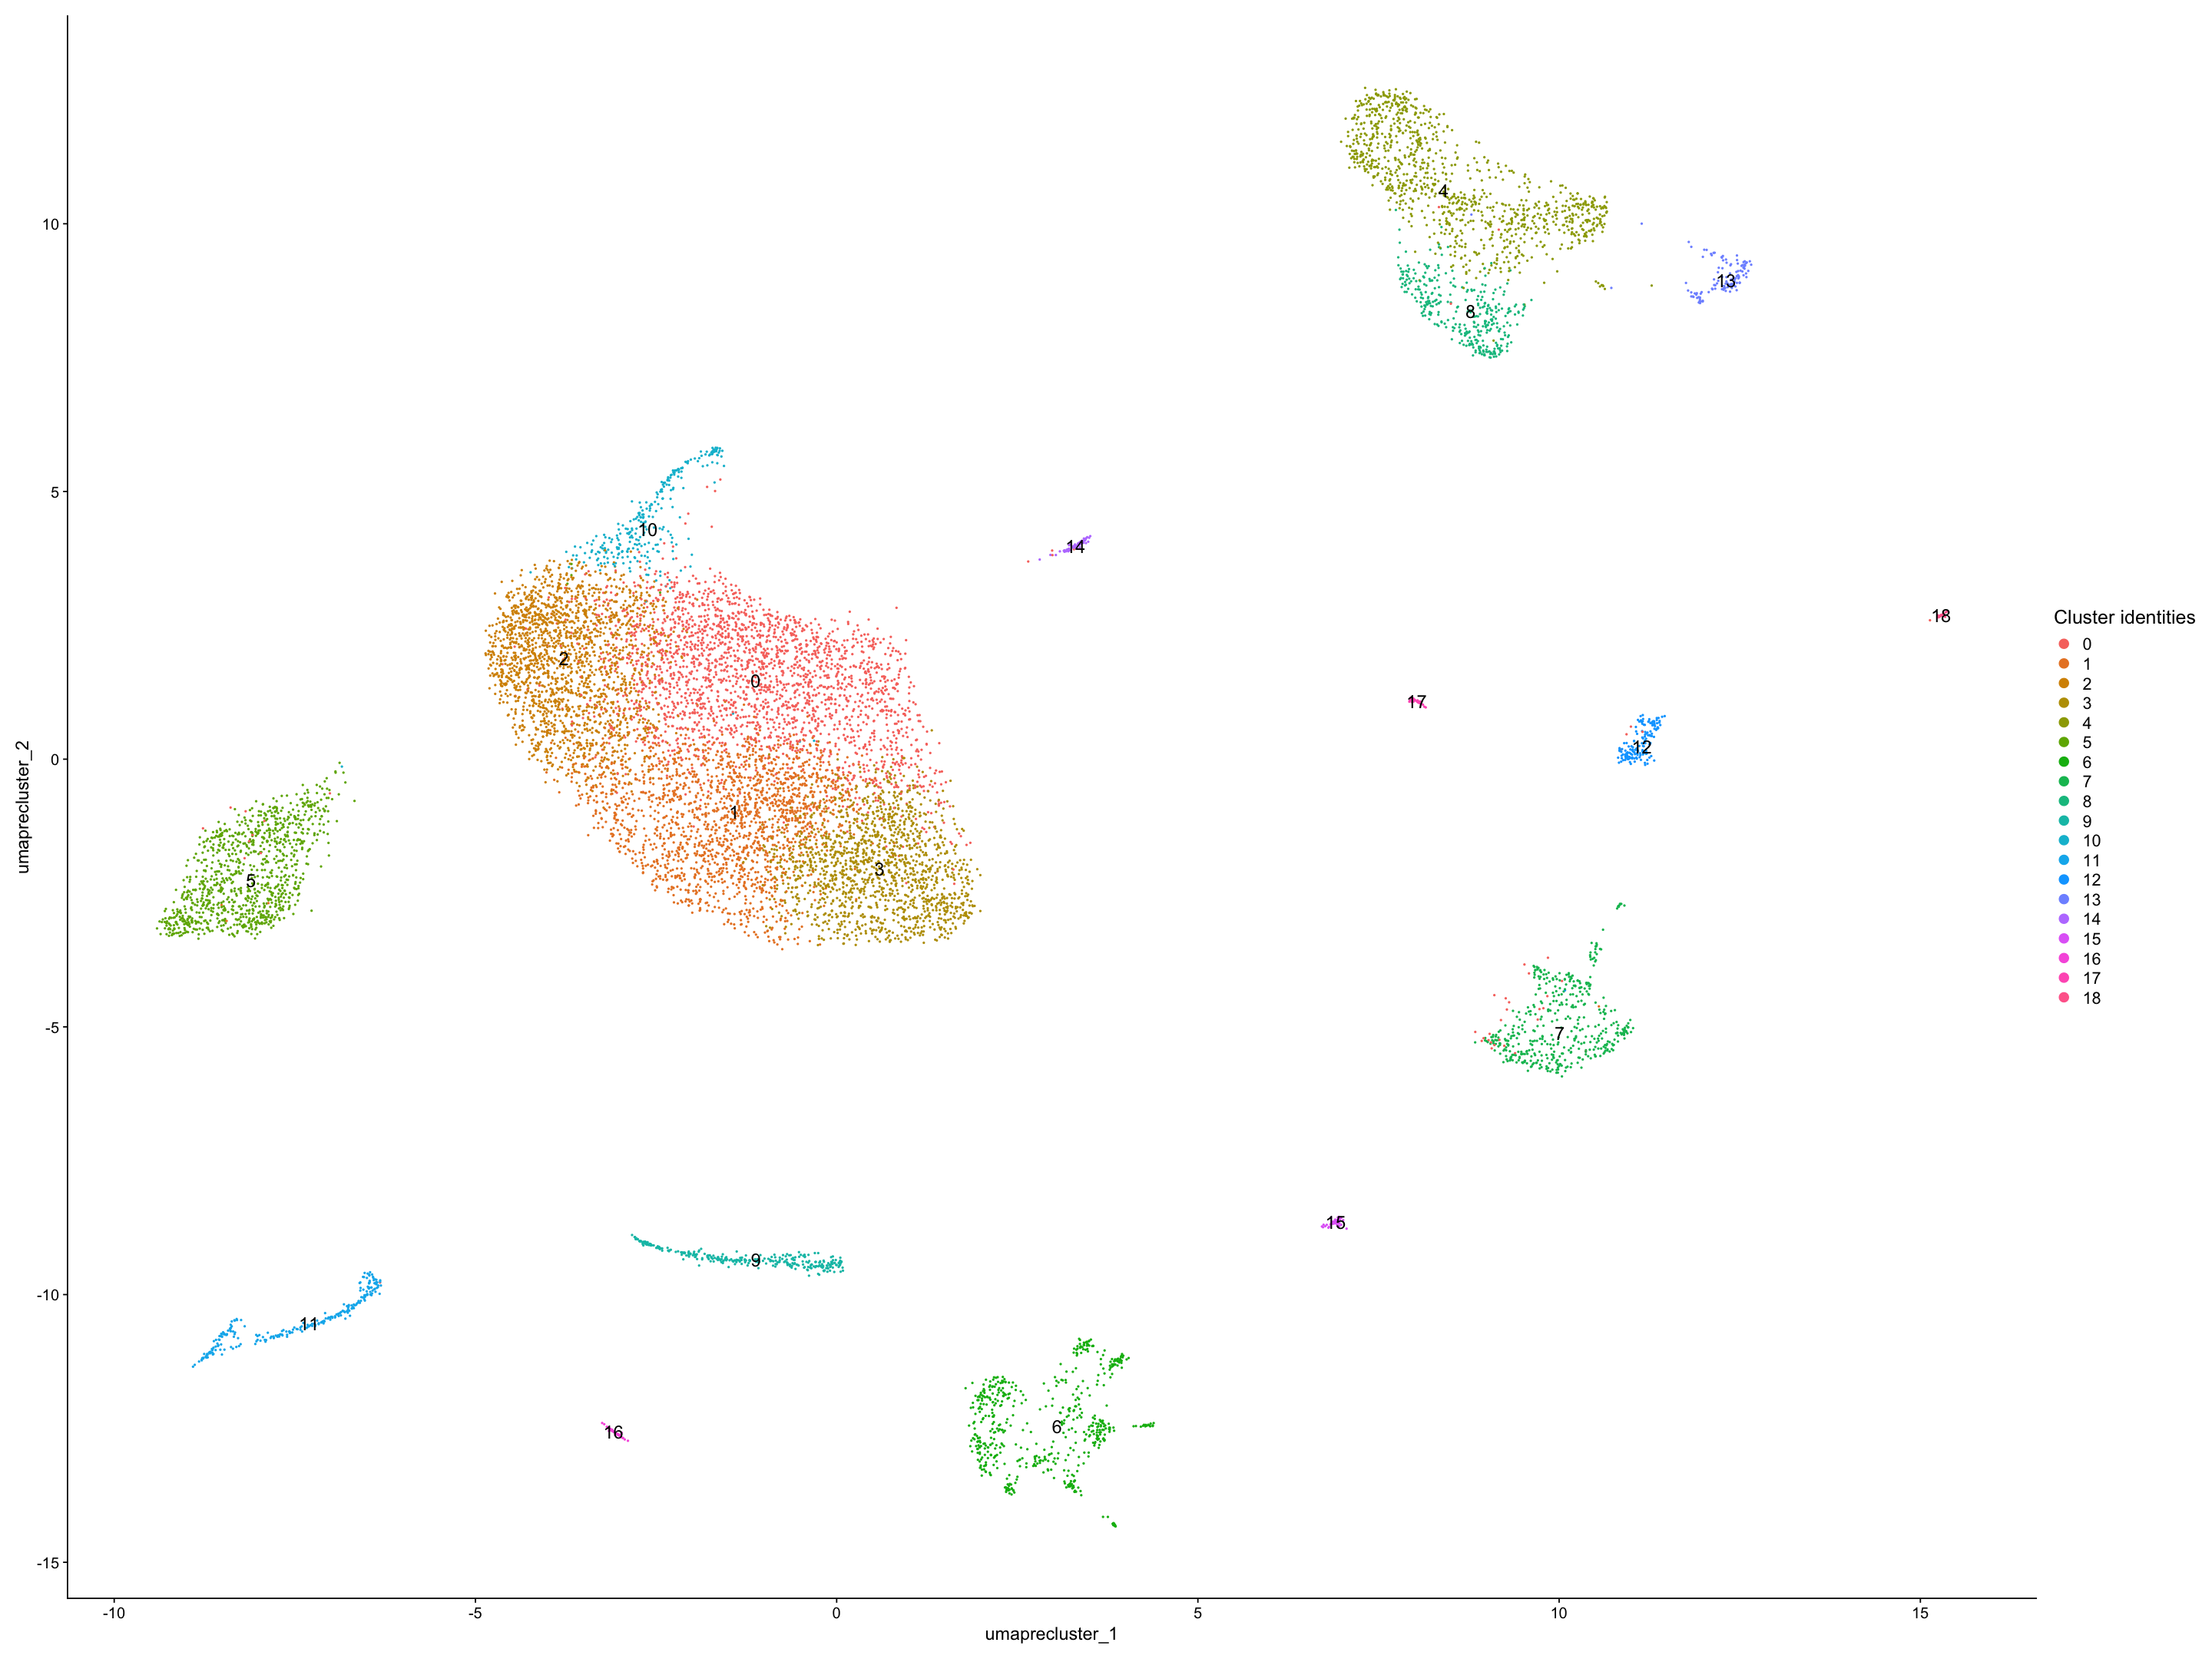

In [42]:
options(repr.plot.width = 24, repr.plot.height = 18)

# DimPlot

# sctype on dimplot
reduction_name = readline(prompt = "Enter the reduction name that was used earlier: ")
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_sc, 
                         reduction = reduction_name, 
                         label = TRUE, repel = FALSE, label.size = 5, group.by = "sctype_classification")  

# cluster numbers on dimplot
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_sc, reduction = reduction_name, label = TRUE, label.size = 5) +  
        labs(color = "Cluster identities") + 
        theme(legend.text = element_text(size = 13),
                  legend.title = element_text(size = 15),
                  plot.title = element_text(size = 22, hjust = 0.5))


In [ ]:
# save LOG_NORM_NOVOALL_filt_integ_final_sc 
dir3 = readline(prompt = "Please enter the file directory to save LOG_NORM_NOVOALL_filt_integ_final_sc") # remember to include the file name and .rds extension
saveRDS(LOG_NORM_NOVOALL_filt_integ_final_sc, file = dir3)

## Filter by gene and expression threhold
Select a gene and expression threshold and remove all below that threshold and run all the dimensional reductions again
- then we could remove a cluster by name or number (code is above)
- GSEA and volcano plots (the differential exp analysis need not be repeated in this file because there is an option to just load in the required data in the actual file)

In [43]:
subset_by_gene = function(seurat_obj, gene, threshold) {
  
  if (!(gene %in% rownames(seurat_obj))) {
    stop("Gene not found in object")
  }

  cells_use = WhichCells(seurat_obj, expression = !!as.name(gene) > threshold)

  seurat_obj = subset(seurat_obj, cells = cells_use)
  return(seurat_obj)
}

In [44]:
gene_name = readline(prompt = "Please enter the gene name you would like to select: ")
threshold_value = readline(prompt = "Please enter the threshold value you would like to select: ")

LOG_NORM_NOVOALL_filt_integ_final_gene = subset_by_gene(LOG_NORM_NOVOALL_filt_integ_final,
                           gene = gene_name,
                           threshold = threshold_value)

LOG_NORM_NOVOALL_filt_integ_final_gene = recluster_func(LOG_NORM_NOVOALL_filt_integ_final_gene, 
                                                    resolution = 0.8, 
                                                    cluster_name = paste0(gene_name, "_clusters"), 
                                                    umap_name = paste0(gene_name, "_umap"))

Please enter the gene name you would like to select:  snap25a
Please enter the threshold value you would like to select:  1


Centering and scaling data matrix

PC_ 1 
Positive:  scg2b, atp1b1b, egr4, nrxn1a, nrn1a, ENSDARG00000105529, bdnf, dnajb4, trim9, glipr1b 
	   homer1b, TENT5D, ENSDARG00000075513, rasd2a, ADGRB1.1, stmn4l, nfil3-6, gap43, nptx1l, ENSDARG00000097648 
	   chn1, camk2a, slc35g2a, pcp4a, nrgna, KDM6B, NELL2, rgs16, dusp5, gng13b 
Negative:  cd63, ENSDARG00000099491, ENSDARG00000096655, itm2bb, arpc1b, ENSDARG00000071437, pfn1, ENSDARG00000105408, zgc:64051, b2m 
	   ENSDARG00000095562, srgn, wasb, ENSDARG00000101785, elovl1b, rgs13, lcp1, mhc1uba, mhc2daa, cd74b 
	   cxcr4b, si:ch211-79k12.1, coro1a, vsir, ENSDARG00000114387, ENSDARG00000016939, ENSDARG00000087645, fcer1g, clic2, ENSDARG00000055504 
PC_ 2 
Positive:  timd4, dhrs12la, csrp1b, ENSDARG00000089255, ENSDARG00000071454, cldnk, ENSDARG00000074285, gjb1a, MYRF, ENSDARG00000095294 
	   ENSDARG00000094045, cd82a, stxbp6l, tmem125b, cdaa, ENSDARG00000113045, ENSDARG00000089828, fabp2, cd9b, zgc:174888 
	   sox10, ninj2, ENSDARG00000

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 21579
Number of edges: 789182

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9179
Number of communities: 30
Elapsed time: 2 seconds


17:10:30 UMAP embedding parameters a = 0.9922 b = 1.112

17:10:30 Read 21579 rows and found 30 numeric columns

17:10:30 Using Annoy for neighbor search, n_neighbors = 30

17:10:30 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:10:32 Writing NN index file to temp file /var/folders/7b/snpms3c90nqg721sdk5lczdw0000gn/T//RtmpdV0v1z/file5134182fb773

17:10:32 Searching Annoy index using 1 thread, search_k = 3000

17:10:36 Annoy recall = 100%

17:10:36 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:10:36 Initializing from normalized Laplacian + noise (using RSpectra)

17:10:38 Commencing optimization for 200 epochs, with 987342 positive edges

17:10:38 Using rng type: pcg

17:10:44 Optimization finished



[1] "Seurat object v5 is used"


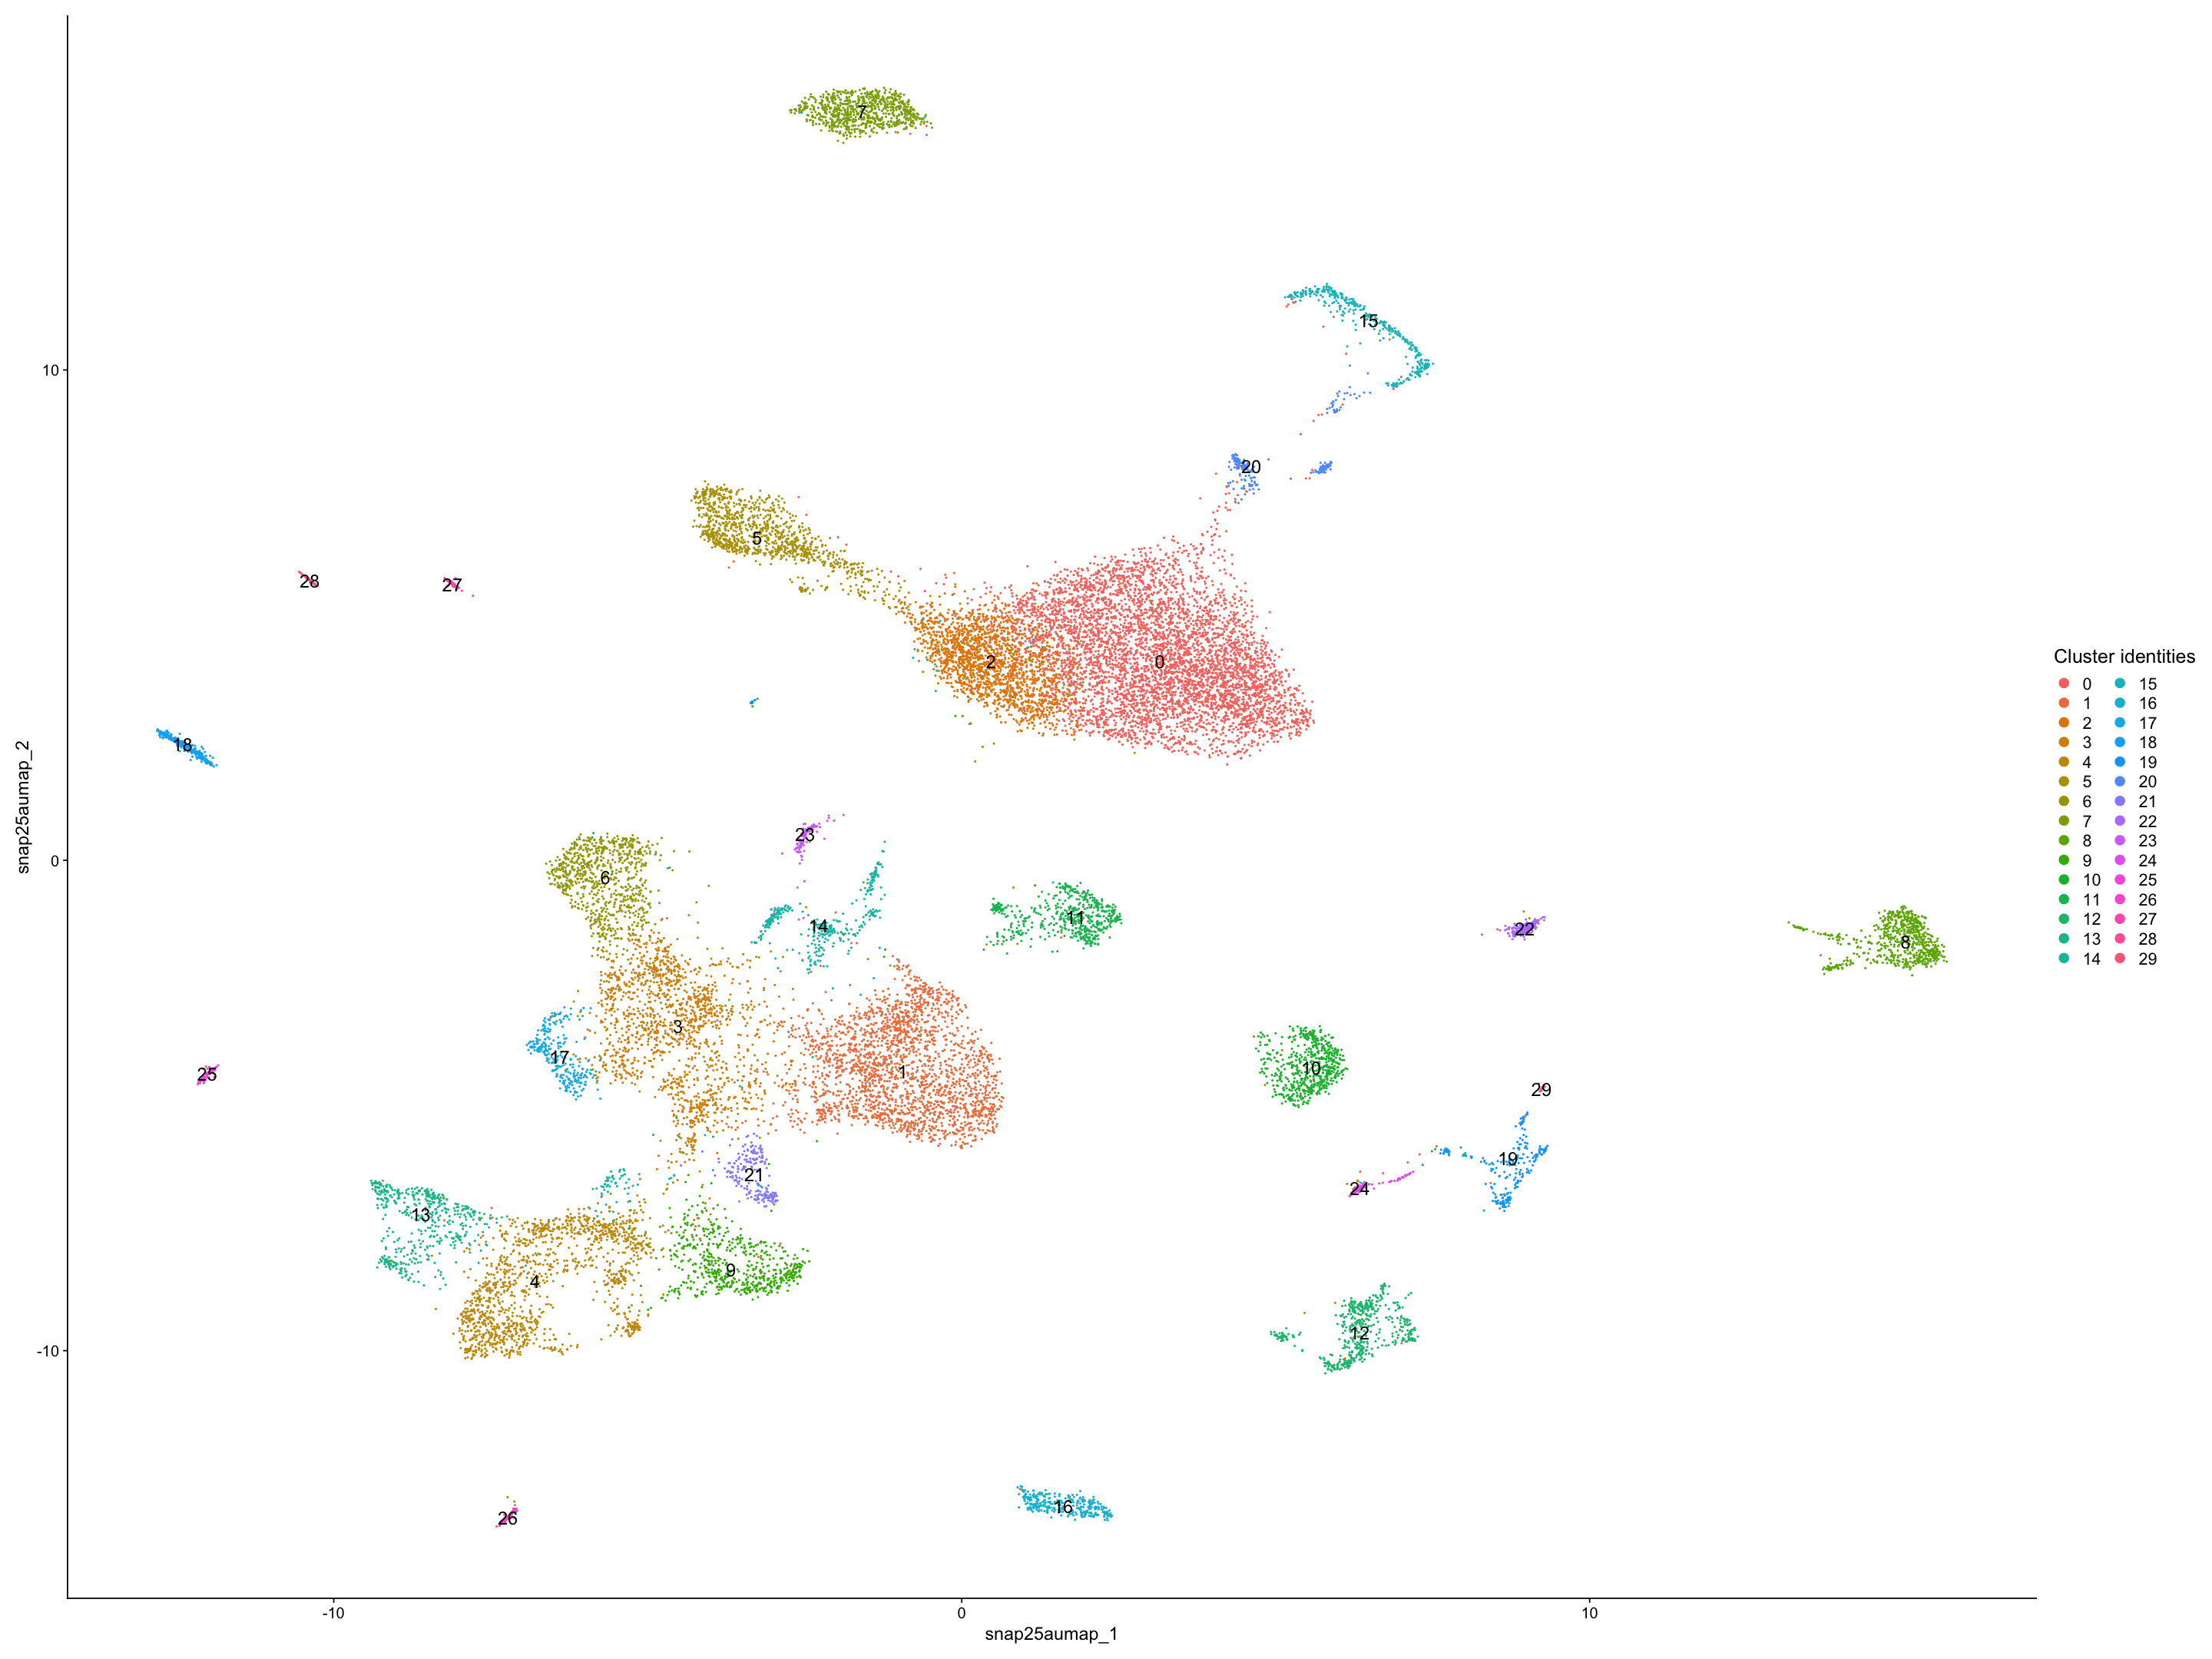

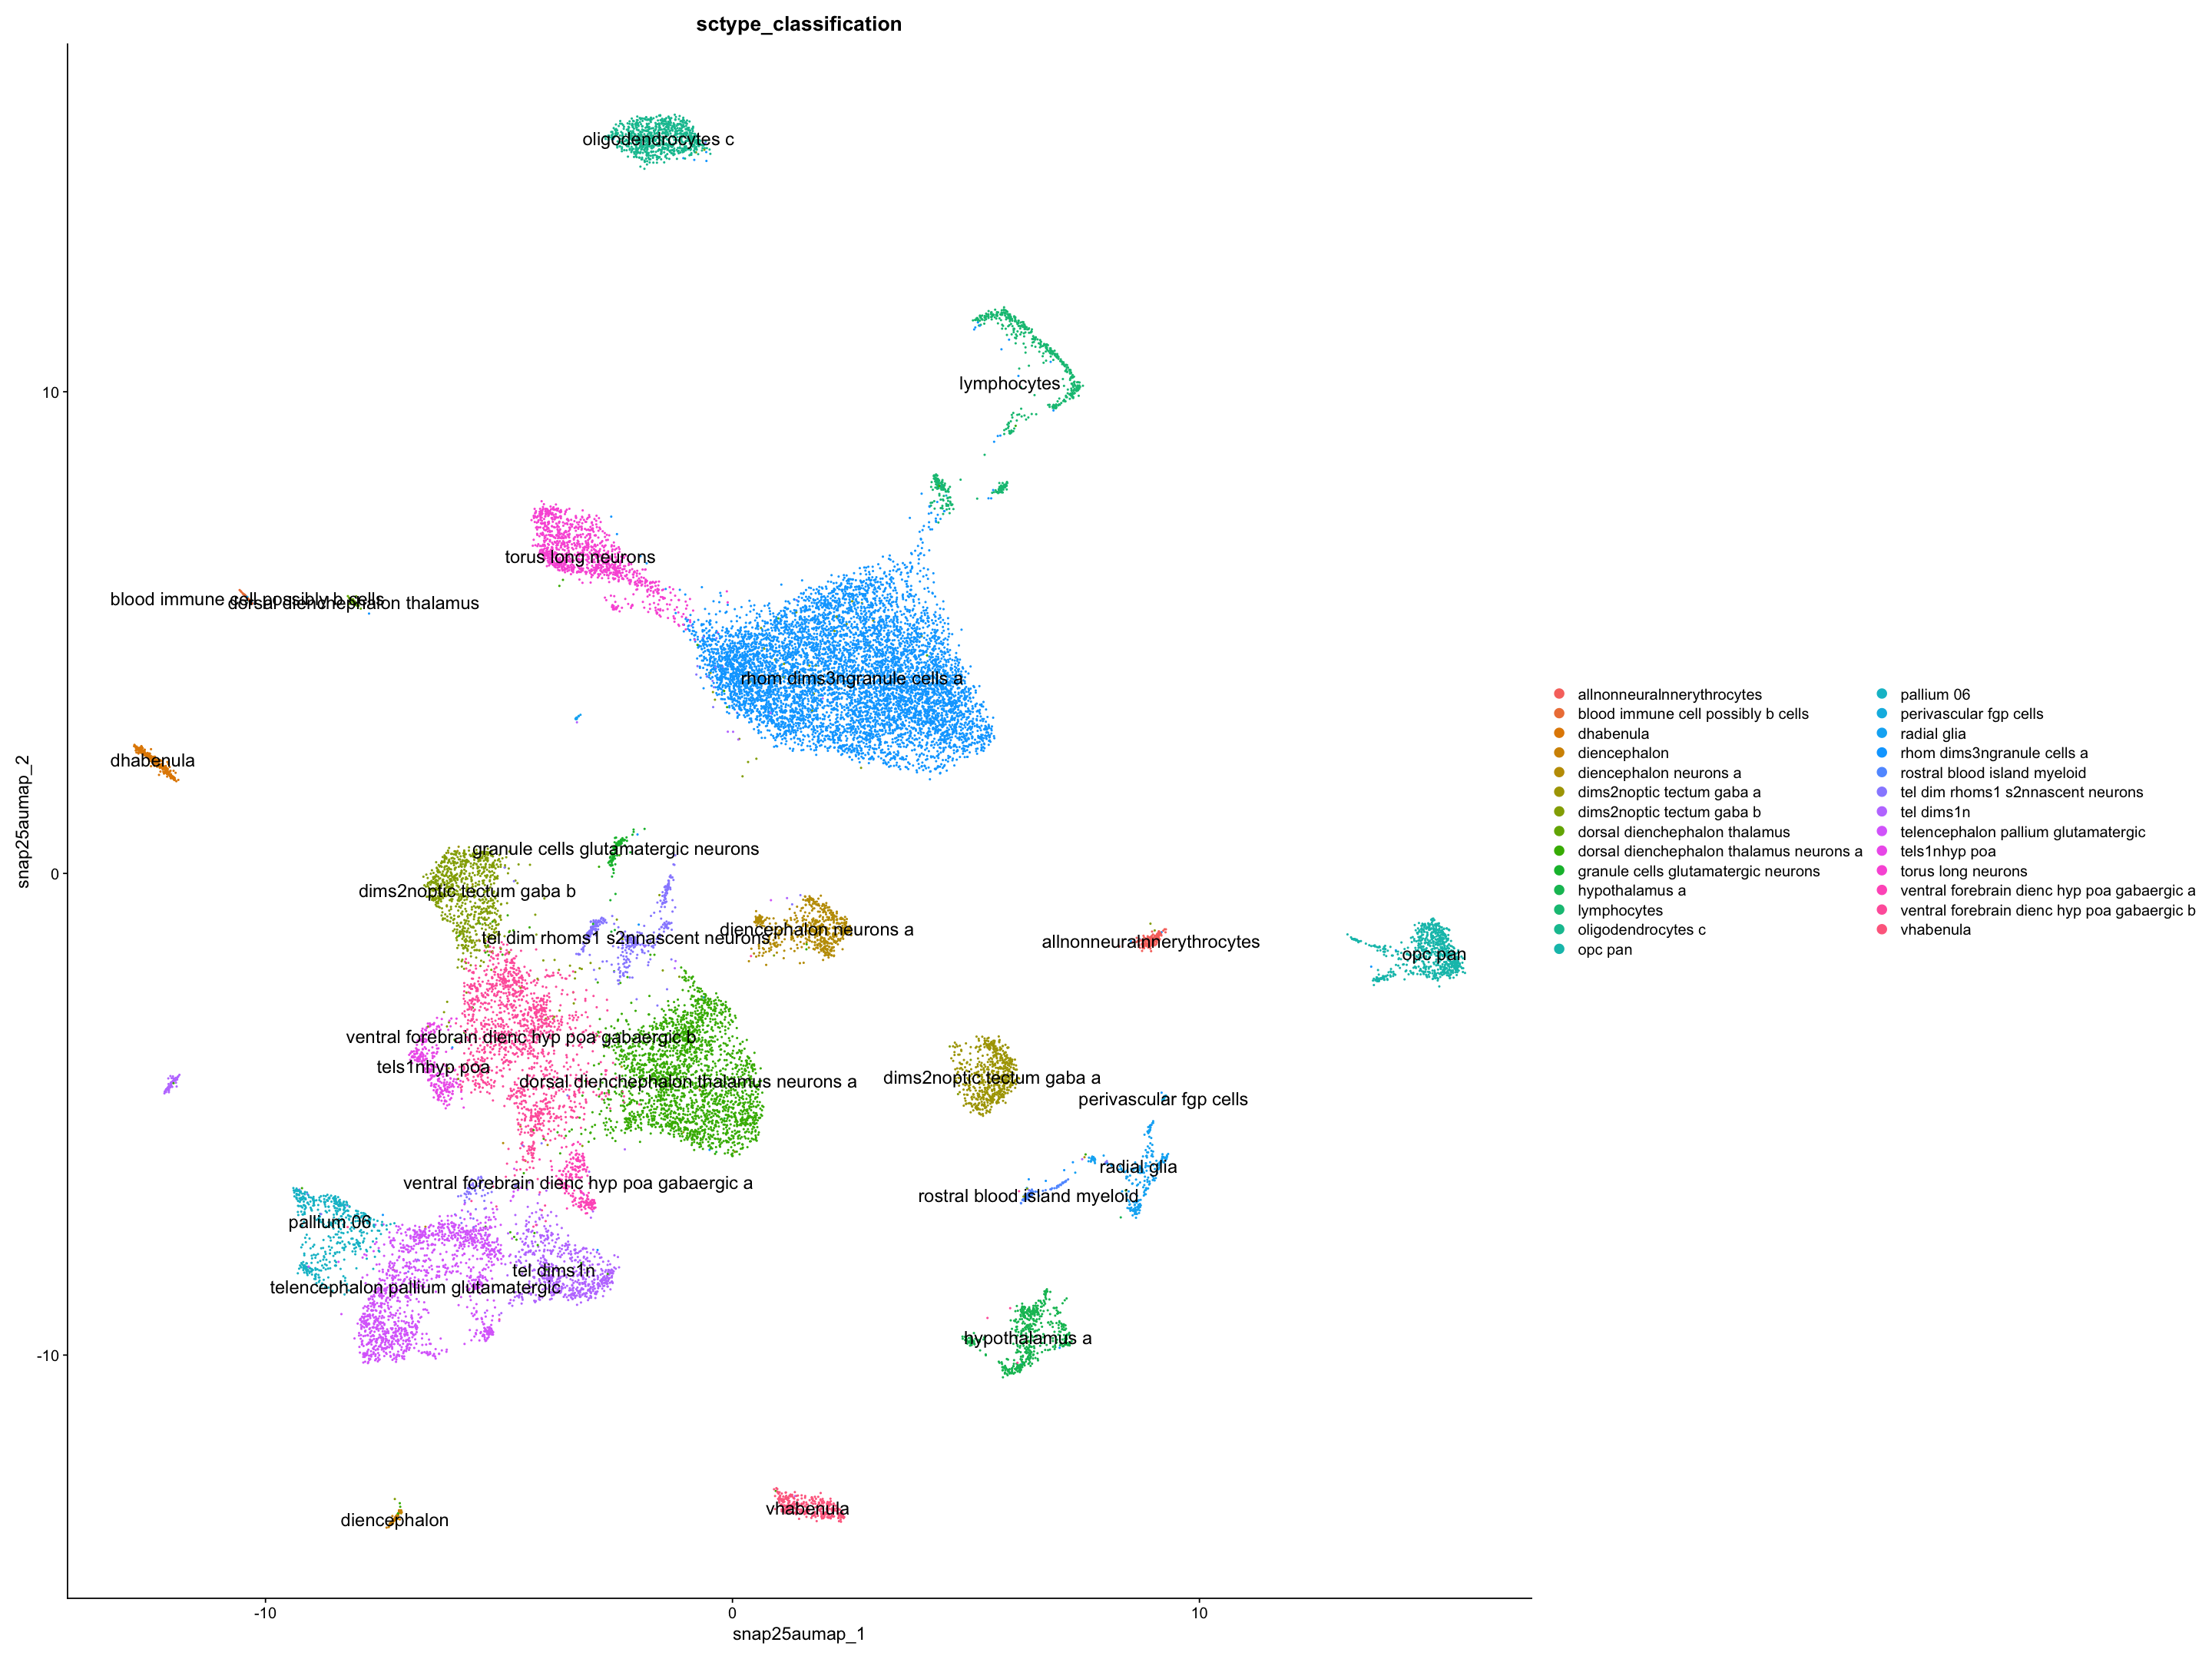

In [45]:
# Dimplot

# cluster numbers
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_gene, reduction = paste0(gene_name, "_umap"), label = TRUE, label.size = 5) +  
        labs(color = "Cluster identities") + 
        theme(legend.text = element_text(size = 13),
                  legend.title = element_text(size = 15),
                  plot.title = element_text(size = 22, hjust = 0.5))

# sctype on dimplot
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_gene, 
                         reduction = paste0(gene_name, "_umap"), 
                         label = TRUE, repel = FALSE, label.size = 5, group.by = "sctype_classification")  

In [ ]:
# save LOG_NORM_NOVOALL_filt_integ_final_gene 
dir4 = readline(prompt = "Please enter the file directory to save LOG_NORM_NOVOALL_filt_integ_final_gene")
saveRDS(LOG_NORM_NOVOALL_filt_integ_final_gene, file = dir4)

## Filter clusters by number
As mentioned, this may be done before and after gene expression filteration as per user choice.

In [49]:
user_clusters = readline(prompt = "Please enter the numbers of the clusters to keep, separated by a comma :")
user_clusters = as.numeric(str_split_1(user_clusters, ","))

Please enter the numbers of the clusters to keep, separated by a comma : 1,2,3,4,5,6,7


In [50]:
LOG_NORM_NOVOALL_filt_integ_final_clust = subset(LOG_NORM_NOVOALL_filt_integ_final, subset = seurat_clusters %in% user_clusters) 
LOG_NORM_NOVOALL_filt_integ_final_clust = recluster_func(LOG_NORM_NOVOALL_filt_integ_final_clust, 
                                                    resolution = 0.8, 
                                                    cluster_name = paste0(gene_name, "_clusters"), 
                                                    umap_name = paste0(gene_name, "_umap"))

Centering and scaling data matrix

PC_ 1 
Positive:  scg2b, atp1b1b, bdnf, gap43, nrxn1a, dnajb4, ADGRB1.1, trim9, TENT5D, glipr1b 
	   nrn1a, KDM6B, slc35g2a, ENSDARG00000105529, egr4, stmn4l, chga, homer1b, ENSDARG00000097648, uchl1 
	   dusp5, adcyap1b, rrad, rtn4rl2a, nrgna, hes6, PPP4R4, kctd4, nptx1l, plk2b 
Negative:  dhrs12la, ENSDARG00000036186, cldnk, ENSDARG00000095294, mpz, ENSDARG00000089255, csrp1b, plp1b, ENSDARG00000074285, cd82a 
	   ENSDARG00000089828, qki2, cd59, timd4, cd9b, stxbp6l, cdaa, ppp1r14aa, ENSDARG00000089477, gjb1a 
	   MYRF, ENSDARG00000071454, LY75, ninj2, fabp2, elovl1b, tuft1a, zgc:174888, tpm1, syngr2b 
PC_ 2 
Positive:  hsp70.2, scg2b, hsp70l, atp1b1b, uchl1, itm2cb, glula, gap43, bdnf, fosb 
	   hsp70.1, ubl3a, nrxn1a, dnajb4, ndrg3a, nrn1a, TENT5D, hspa8b, trim9, slc35g2a 
	   ADGRB1.1, nfil3-6, stmn4l, ENSDARG00000105529, glipr1b, chmp6b, tppp2, egr4, vim, PPP4R4 
Negative:  srgn, ENSDARG00000114387, si:ch211-165d12.4, b2m, pfn1, sla2b, wasb, ENS

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 12685
Number of edges: 462662

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8905
Number of communities: 20
Elapsed time: 1 seconds


17:14:32 UMAP embedding parameters a = 0.9922 b = 1.112

17:14:32 Read 12685 rows and found 30 numeric columns

17:14:32 Using Annoy for neighbor search, n_neighbors = 30

17:14:32 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

17:14:32 Writing NN index file to temp file /var/folders/7b/snpms3c90nqg721sdk5lczdw0000gn/T//RtmpdV0v1z/file51344e230bdf

17:14:32 Searching Annoy index using 1 thread, search_k = 3000

17:14:34 Annoy recall = 100%

17:14:34 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

17:14:35 Initializing from normalized Laplacian + noise (using RSpectra)

17:14:35 Commencing optimization for 200 epochs, with 534634 positive edges

17:14:35 Using rng type: pcg

17:14:39 Optimization finished



[1] "Seurat object v5 is used"


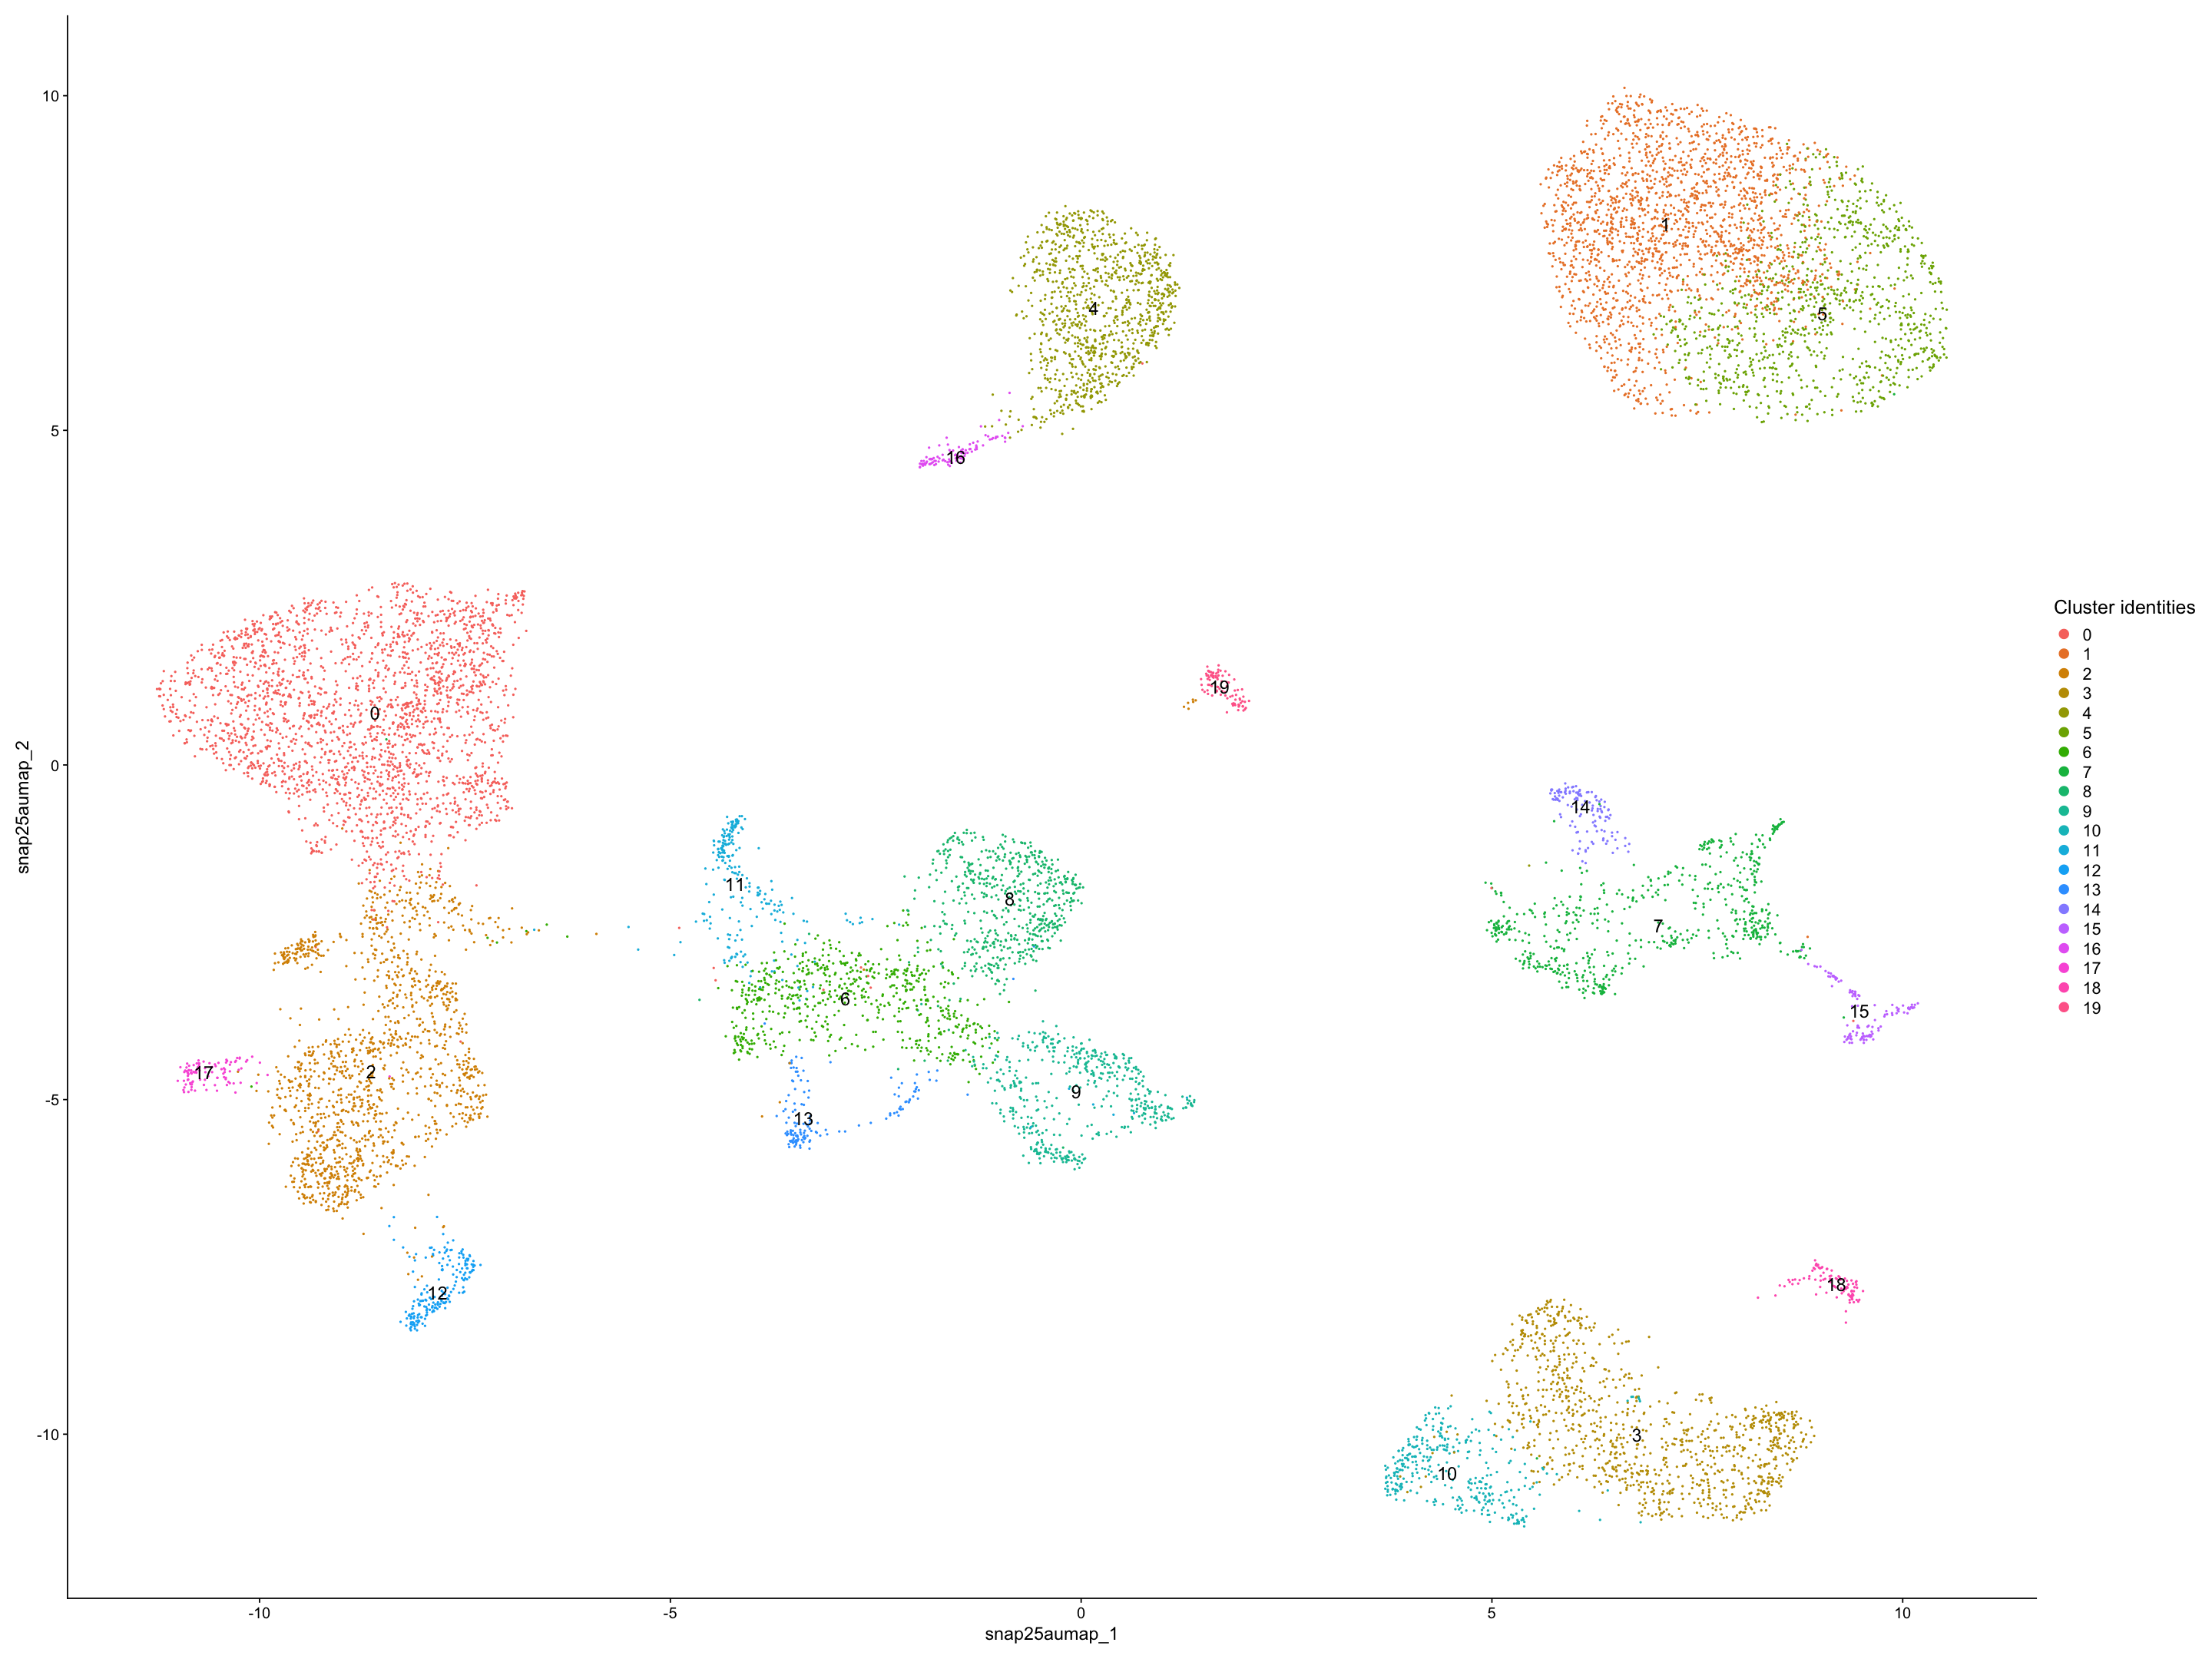

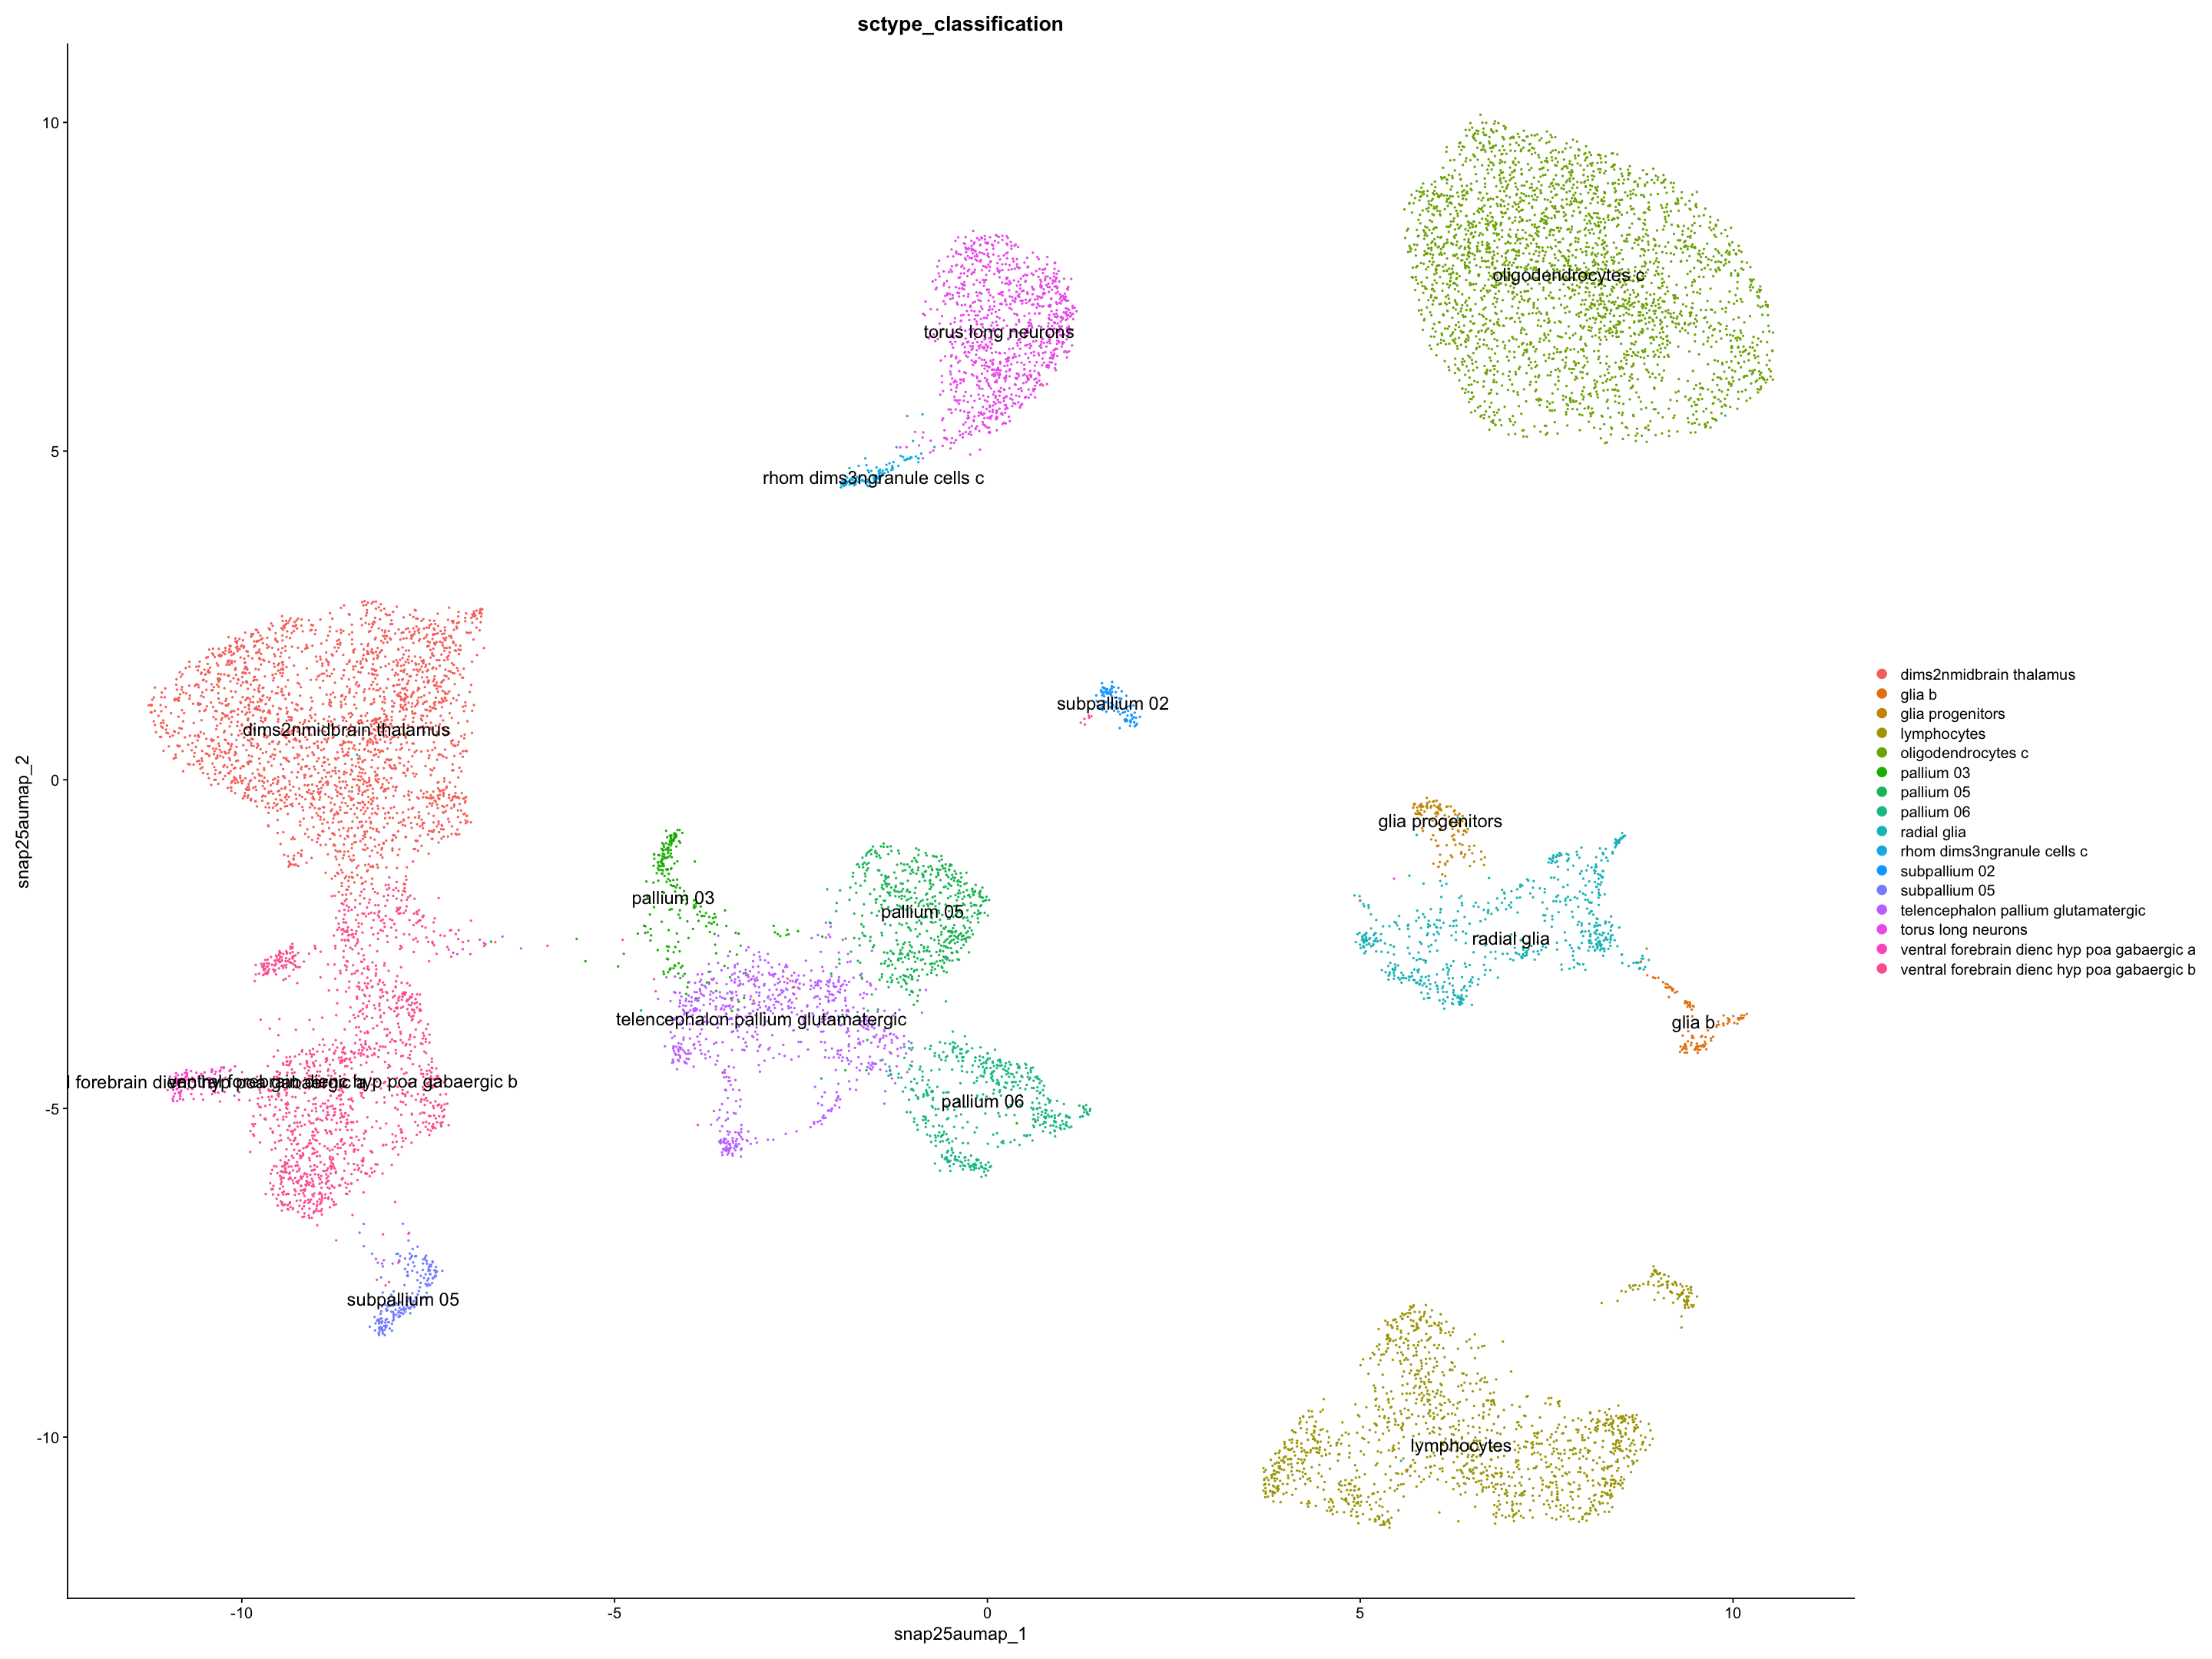

In [51]:
# Dimplot

# cluster numbers on dimplot
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_clust, reduction = paste0(gene_name, "_umap"), label = TRUE, label.size = 5) +  
        labs(color = "Cluster identities") + 
        theme(legend.text = element_text(size = 13),
                  legend.title = element_text(size = 15),
                  plot.title = element_text(size = 22, hjust = 0.5))

# sctype on dimplot
DimPlot(LOG_NORM_NOVOALL_filt_integ_final_clust, 
                         reduction = paste0(gene_name, "_umap"), 
                         label = TRUE, repel = FALSE, label.size = 5, group.by = "sctype_classification")

In [ ]:
# save LOG_NORM_NOVOALL_filt_integ_final_clust 
dir5 = readline(prompt = "Please enter the file directory to save LOG_NORM_NOVOALL_filt_integ_final_clust")
saveRDS(LOG_NORM_NOVOALL_filt_integ_final_clust, file = dir5)